# HR Attrition – Data Source

## 1. Data Source

Notebook này trình bày bước **Data Source** trong quy trình khai phá dữ liệu tổng quát:
**Nguồn dữ liệu → Tiền xử lý → Đặc trưng → Mô hình → Đánh giá**

Mục tiêu của bước này:
- Giới thiệu nguồn dữ liệu
- Hiểu cấu trúc và schema dữ liệu
- Xác định bài toán khai phá dữ liệu
- Phân loại các biến

⚠️ Notebook này **chưa thực hiện tiền xử lý hay mô hình hóa**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
# Đọc dữ liệu gốc
DATA_PATH = "../data/raw/HR_Analytics.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,SalarySlab,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,1,405,3,Male,54,3,1,Laboratory Technician,3,Single,1420,Upto 5k,25233,1,Y,No,13,3,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,1,411,4,Female,69,2,1,Sales Representative,3,Single,1200,Upto 5k,9724,1,Y,No,12,3,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,1,614,2,Male,69,3,1,Sales Representative,2,Single,1878,Upto 5k,8059,1,Y,Yes,14,3,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,1,1012,2,Male,73,3,1,Research Scientist,4,Single,1051,Upto 5k,13493,1,Y,No,15,3,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,1,1156,3,Male,80,3,1,Laboratory Technician,3,Single,1904,Upto 5k,13556,1,Y,No,12,3,4,80,0,0,0,3,0,0,0,0.0


In [3]:
print("KÍCH THƯỚC DỮ LIỆU")
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

KÍCH THƯỚC DỮ LIỆU
Số dòng: 1480
Số cột: 38


In [4]:
# Thông tin schema
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

In [5]:
# Mô tả dữ liệu
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1480.0,36.917568,9.128559,18.0,30.00,36.0,43.00,60.0
DailyRate,1480.0,801.384459,403.126988,102.0,465.00,800.0,1157.00,1499.0
DistanceFromHome,1480.0,9.220270,8.131201,1.0,2.00,7.0,14.00,29.0
Education,1480.0,2.910811,1.023796,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1480.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1480.0,1031.860811,605.955046,1.0,493.75,1027.5,1568.25,2068.0
EnvironmentSatisfaction,1480.0,2.724324,1.092579,1.0,2.00,3.0,4.00,4.0
HourlyRate,1480.0,65.845270,20.328266,30.0,48.00,66.0,83.00,100.0
JobInvolvement,1480.0,2.729730,0.713007,1.0,2.00,3.0,3.00,4.0
JobLevel,1480.0,2.064865,1.105574,1.0,1.00,2.0,3.00,5.0


### 1.1 Mô tả Dataset

- Nguồn dữ liệu: HR Analytics Dataset (Kaggle)
- Số bản ghi: 1480 nhân viên
- Số thuộc tính: 35
- Mỗi dòng dữ liệu tương ứng với **một nhân viên**

Dataset chứa thông tin về:
- Nhân khẩu học
- Công việc và vai trò
- Thu nhập và đãi ngộ
- Mức độ hài lòng và hiệu suất
- Thâm niên làm việc
- Trạng thái nghỉ việc (Attrition)

### 1.2 Bài toán khai phá dữ liệu

Biến mục tiêu chính của đề tài là:

- **Attrition**: Nhân viên có nghỉ việc hay không
  - Yes: nghỉ việc
  - No: tiếp tục làm việc

👉 Đây là **bài toán phân lớp nhị phân (Binary Classification)**.

Ngoài ra, dataset còn được sử dụng cho:
- Luật kết hợp (tìm tổ hợp dẫn đến nghỉ việc)
- Phân cụm nhân viên
- Hồi quy mức độ hài lòng / hiệu suất
- Bán giám sát (giả lập thiếu nhãn Attrition)


In [6]:
# Phân bố biến mục tiêu
df["Attrition"].value_counts()
df["Attrition"].value_counts(normalize=True)

Attrition
No     0.839189
Yes    0.160811
Name: proportion, dtype: float64

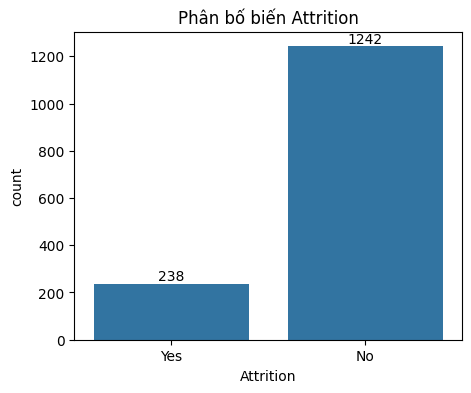

In [7]:
# Biểu đồ phân bố biến mục tiêu
plt.figure(figsize=(5,4))
ax = sns.countplot(data=df, x="Attrition")

plt.title("Phân bố biến Attrition")

# Ghi số lượng lên đầu mỗi cột
for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom'
    )

plt.show()

### 1.3 Nhận xét về phân bố nhãn

- Dataset có hiện tượng **mất cân bằng lớp nhẹ**
- Số nhân viên nghỉ việc ít hơn đáng kể so với số nhân viên ở lại

👉 Do đó, trong các bài toán phân lớp:
- Accuracy **không phải** metric phù hợp
- Sẽ ưu tiên sử dụng:
  - recall
  - F1-score
  - precision
  - PR-AUC

### 1.4 Phân loại biến

**Biến mục tiêu**
- Attrition (Binary)

**Biến số (Numerical)**
- Age
- MonthlyIncome
- DailyRate
- HourlyRate
- MonthlyRate
- DistanceFromHome
- TotalWorkingYears
- YearsAtCompany
- YearsInCurrentRole
- YearsSinceLastPromotion
- YearsWithCurrManager
- NumCompaniesWorked

**Biến thứ bậc (Ordinal)**
- Education
- JobLevel
- JobInvolvement
- JobSatisfaction
- EnvironmentSatisfaction
- RelationshipSatisfaction
- WorkLifeBalance
- PerformanceRating
- StockOptionLevel

**Biến phân loại (Categorical)**
- Department
- JobRole
- Gender
- MaritalStatus
- EducationField
- BusinessTravel
- SalarySlab

**Biến nhị phân**
- OverTime
- Attrition

### 1.5 Kết luận Data Source

Dataset HR Attrition có cấu trúc rõ ràng, đa dạng loại biến và phù hợp cho nhiều kỹ thuật khai phá dữ liệu như:
- Luật kết hợp
- Phân cụm
- Phân lớp
- Bán giám sát

Trong các bước tiếp theo, dữ liệu sẽ được:
- Làm sạch và tiền xử lý
- Chuẩn hóa và mã hóa
- Trích xuất đặc trưng
- Áp dụng các mô hình khai phá dữ liệu